# ANALYSIS OF SCORES

In [1]:
from src.score import Score
from src.linear_predictor import LinearPredictor
import os
import src.constants as cn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.biomodels_iterator import BiomodelsIterator
from src.trajectory import Trajectory
from src.trajectory_collection import TrajectoryCollection
from src.multiple_linear_predictor import MultipleLinearPredictor

# Timeseries Plots

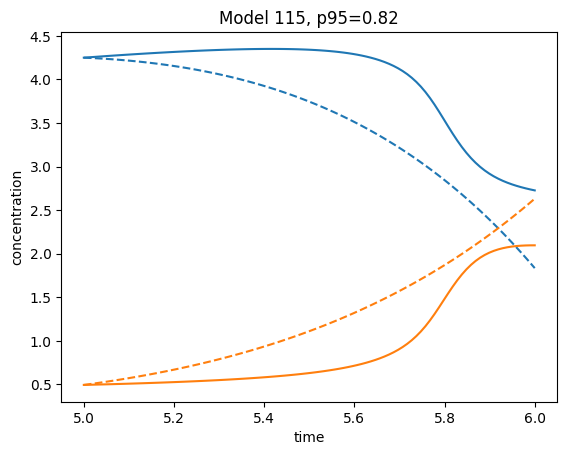

In [2]:
def plotModel(model_num, start_time=0, end_time=None, **kwargs):
    predictor = LinearPredictor.makeFromBiomodels(model_num=model_num, 
                start_time=start_time, end_time=end_time, num_step=-1, num_point=100,
                jacobian_selection=cn.JAC_FITTED)
    df = predictor.score()
    score_p95 = df.loc[0, 'p95']
    _ = predictor.plotPrediction(title=f"Model {model_num}, p95={score_p95:.2f}", **kwargs)

plotModel(115, start_time=5, end_time=6, legend=False)

Processing model: BIOMD0000000001
Failed on model 1
Processing model: BIOMD0000000002
Failed on model 2
Processing model: BIOMD0000000003
Processing model: BIOMD0000000004
Failed on model 4
Processing model: BIOMD0000000005
Failed on model 5
Processing model: BIOMD0000000006
Failed on model 6
Processing model: BIOMD0000000007
Failed on model 7
Processing model: BIOMD0000000008
Processing model: BIOMD0000000009
Failed on model 9
Processing model: BIOMD0000000010
Skipping model BIOMD0000000011 with number 11
Skipping model BIOMD0000000012 with number 12
Skipping model BIOMD0000000013 with number 13
Skipping model BIOMD0000000014 with number 14
Skipping model BIOMD0000000015 with number 15
Skipping model BIOMD0000000016 with number 16
Skipping model BIOMD0000000017 with number 17
Skipping model BIOMD0000000018 with number 18
Skipping model BIOMD0000000019 with number 19
Skipping model BIOMD0000000020 with number 20
Skipping model BIOMD0000000021 with number 21
Skipping model BIOMD00000000

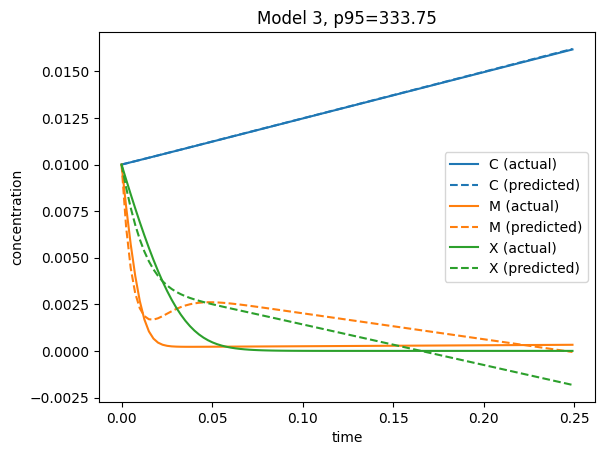

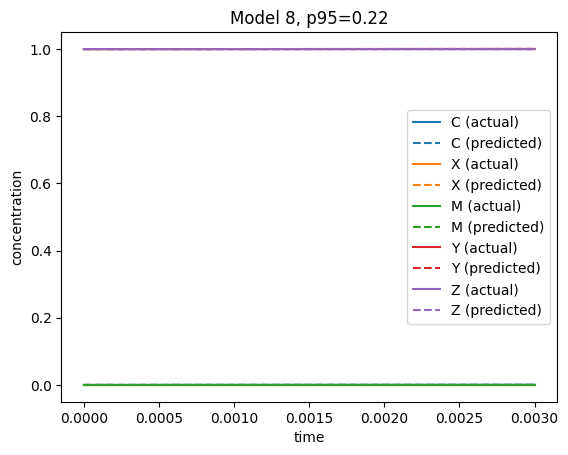

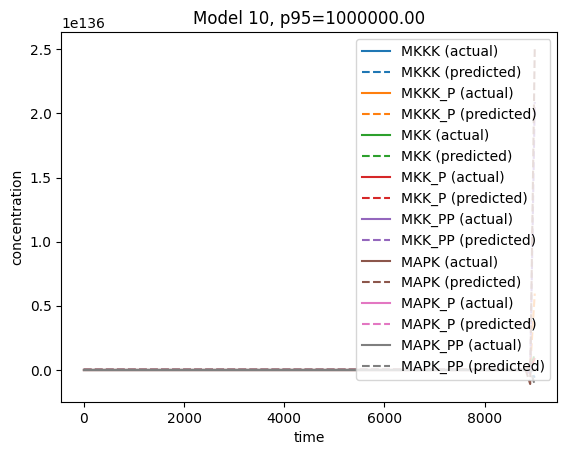

In [3]:
iterator = BiomodelsIterator(
            is_report=True,
            #excluded_models=excluded_models,
            first_model_num=1,
            last_model_num=10)
for item in iterator:
    if item.model_num in [11, 12, 14, 19]:
        print(f"Excluding model {item.model_num}")
        continue
    try:
        plotModel(item.model_num)
    except:
        print(f"Failed on model {item.model_num}")
    

# Splitting

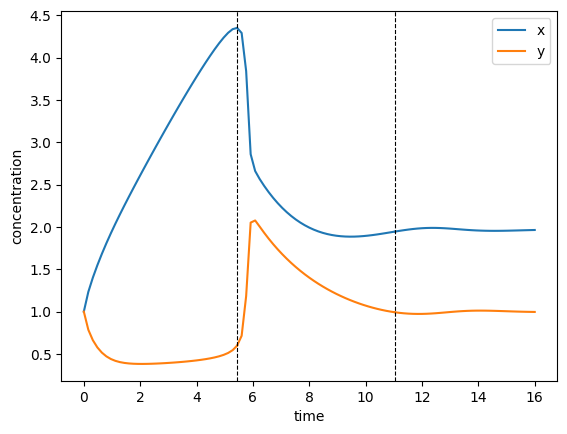

In [4]:
trajectory = Trajectory.makeBiomodel(115)
tc = TrajectoryCollection.split(trajectory, [5.4, 11])
tc.plotTimecourse()

In [5]:
LinearPredictor(tc.trajectories[0], num_step=-1).score()

,description,aggregation_type,mean,min,max,median,p25,p30,p75,p95,p99,count
0,,model,0.511144,0.000093,1.170234,0.156251,0.050768,0.060493,1.074340,1.166237,1.169581,68
1,,x,0.054912,0.000093,0.104748,0.050165,0.033474,0.036838,0.080117,0.102847,0.104721,34
2,,y,0.967377,0.207754,1.170234,1.075758,0.884486,0.933382,1.148760,1.169220,1.169912,34


In [6]:
LinearPredictor(tc.trajectories[1], num_step=-1).score()

,description,aggregation_type,mean,min,max,median,p25,p30,p75,p95,p99,count
0,,model,0.358667,0.00184,1.804804,0.400565,0.207775,0.212765,0.479402,0.514759,1.315152,70
1,,x,0.473857,0.33875,0.519095,0.477560,0.470108,0.472788,0.493036,0.513989,0.518092,35
2,,y,0.243476,0.00184,1.804804,0.207436,0.144567,0.161200,0.218871,0.500545,1.563526,35


0.7885775961134782
4.183979332435164


(None, None)

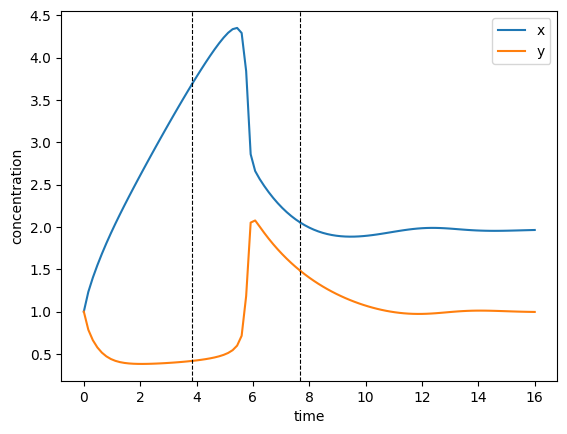

In [7]:
tc = TrajectoryCollection.autoSplit(trajectory, num_split=2)
tc.plotTimecourse()
print(LinearPredictor(tc.trajectories[0]).cost), print(LinearPredictor(tc.trajectories[1]).cost)

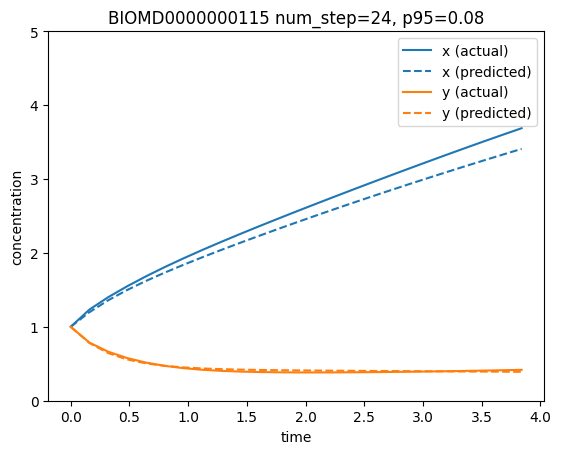

In [8]:
LinearPredictor(tc.trajectories[0]).score()
LinearPredictor(tc.trajectories[0], num_step=-1, jacobian_selection=cn.JAC_FITTED).plotPrediction(ylim=[0,5])

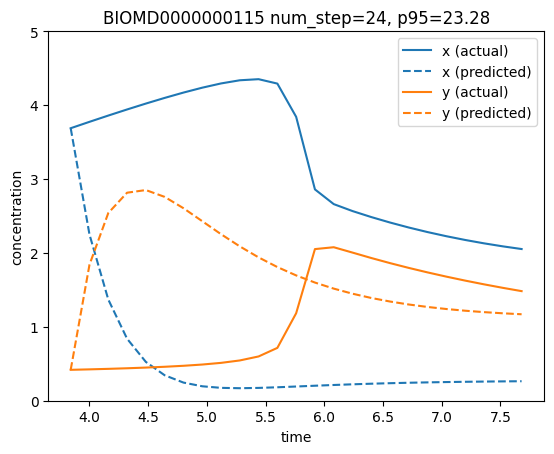

In [9]:
LinearPredictor(tc.trajectories[1]).score()
LinearPredictor(tc.trajectories[1]).plotPrediction(ylim=[0,5])

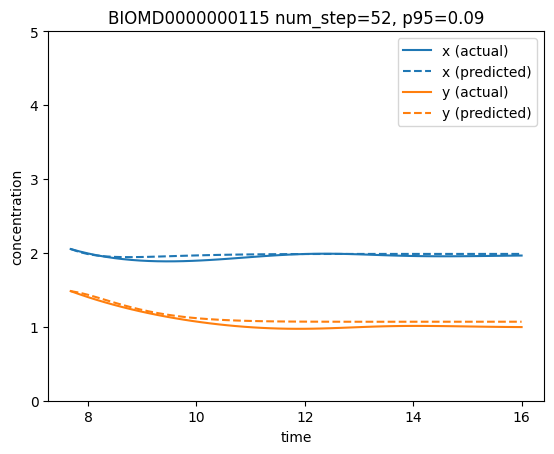

In [10]:
LinearPredictor(tc.trajectories[2]).score()
LinearPredictor(tc.trajectories[2], jacobian_selection=cn.JAC_FITTED).plotPrediction(ylim=[0,5])

## Use MultipleLinearPredictor

Cannot use JAC_FITTED: num_species (30) > num_point (5).
> /Users/jlheller/home/Technical/repos/model_linearity_analysis/src/multiple_linear_predictor.py(129)plotPrediction()
    127                     color=color, linestyle="--", label=f"{name} (predicted)")
    128         for traj in self.trajectory_collection.trajectories[:-1]:
--> 129             ax.axvline(x=traj.end_time, color="black",  # type: ignore
    130                     linestyle="--", linewidth=0.8)
    131         plot_options.apply()



ipdb>  c


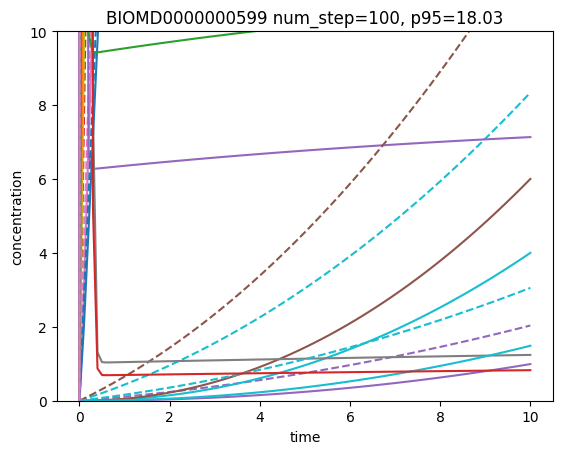

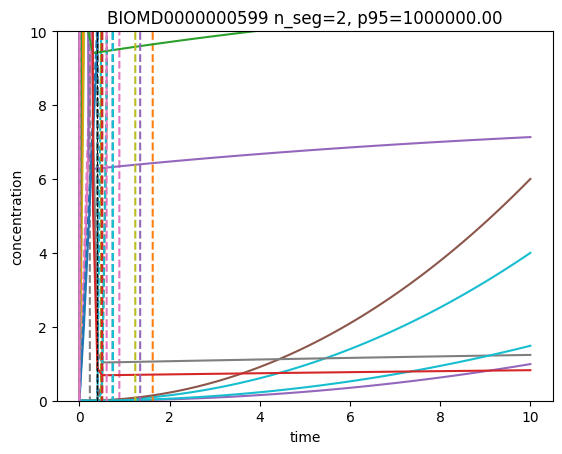

In [24]:
def evaluateMlp(model_num, num_split=2, **kwargs):
    trajectory = Trajectory.makeBiomodel(model_num=model_num, end_time=10)
    tc = TrajectoryCollection.autoSplit(trajectory, num_split=num_split)
    #
    lp = LinearPredictor(trajectory)
    lp.plotPrediction(**kwargs)
    #
    mlp = MultipleLinearPredictor(tc)
    mlp.plotPrediction(**kwargs)

evaluateMlp(599, num_split=1, ylim=[0, 10], legend=False)

# Histograms

## Aggregate Data

In [ ]:
ffiles = [f for f in os.listdir(cn.DATA_DIR) if "linear_predictor_score" in f]
dfs = []
for ffile in ffiles:
    df = pd.read_csv(os.path.join(cn.DATA_DIR, ffile))
    dfs.append(df)
merged_df = pd.concat(dfs)
ALL_DF = merged_df.reset_index()
ALL_PATH = "all_data.csv"
ALL_DF.to_csv(ALL_PATH)

In [ ]:
MODEL_DF = ALL_DF[ALL_DF["aggregation_type"] == "model"]
p95_arr = np.sort(MODEL_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(MODEL_DF)} Models")

In [ ]:
SPECIES_DF = ALL_DF[ALL_DF["aggregation_type"] != "model"]
p95_arr = np.sort(SPECIES_DF["p95"].values)
count = len(p95_arr)
_, ax = plt.subplots()
ax.plot(p95_arr, np.array(range(count))/count)
ax.set_xlim(0, 1)
ax.set_title(f"RAE 95th Percentile for {len(SPECIES_DF)} Species")